# 📚 Guide Pédagogique : Détection d'Anomalies dans les Réseaux de Paiements

Ce notebook explique **pas à pas** tous les concepts utilisés dans le système de détection d'anomalies.

## 📖 Table des matières

1. [Introduction : Les Graphes de Transactions](#partie-1)
2. [Métriques de Centralité](#partie-2)
3. [Embeddings de Graphe](#partie-3)
4. [Features Transactionnelles](#partie-4)
5. [Les 6 Facteurs de Risque](#partie-5)
6. [Isolation Forest Expliqué](#partie-6)
7. [Mise en Pratique](#partie-7)

In [21]:
# Installation des bibliothèques nécessaires
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

# Configuration graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

---

# <a name="partie-1"></a>1️⃣ Introduction : Les Graphes de Transactions

## 🤔 Qu'est-ce qu'un graphe ?

Un **graphe** est une structure mathématique composée de :
- **Nœuds** (ou sommets) : les entités
- **Arêtes** (ou liens) : les relations entre entités

### Dans notre cas :
- **Nœuds** = Clients et Tiers (fournisseurs)
- **Arêtes** = Transactions (paiements)

### Exemple simple

Imaginons 3 clients et 3 fournisseurs :

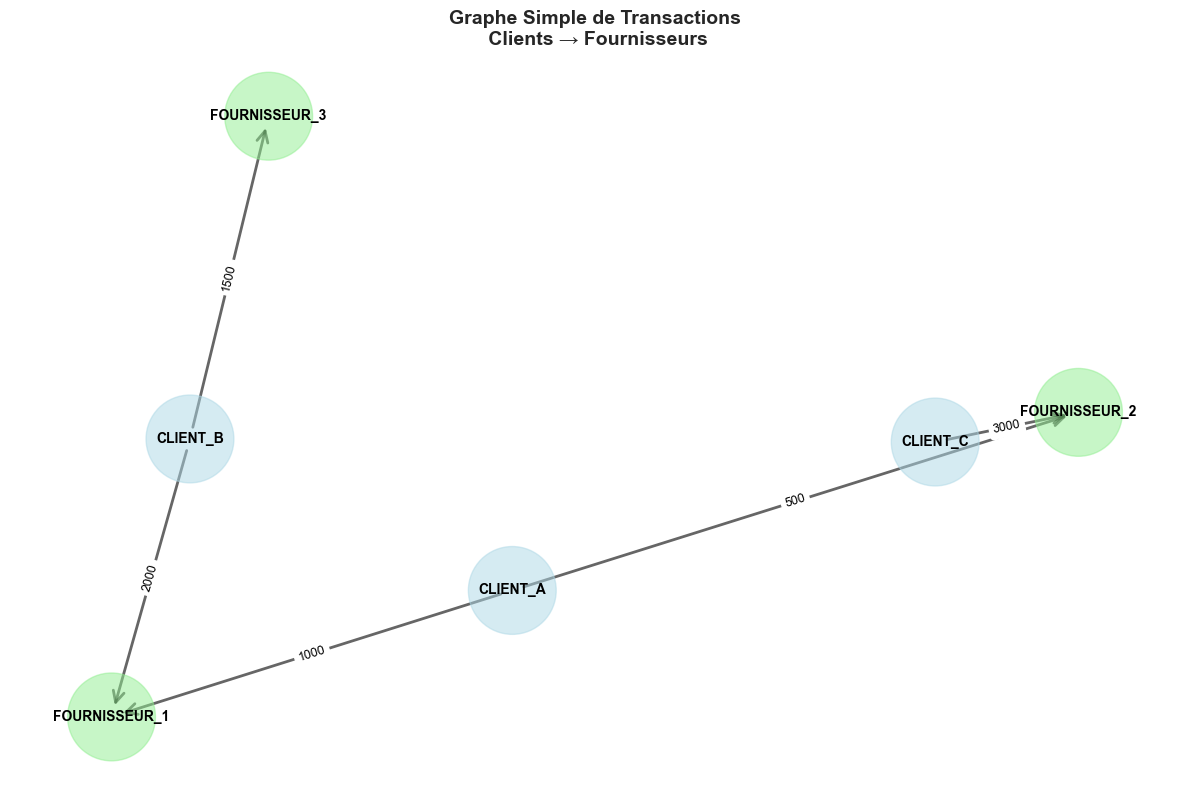


📊 Statistiques du graphe :
  Nombre de nœuds : 6
  Nombre d'arêtes (transactions) : 5
  Densité : 0.167


In [22]:
# Créer un exemple simple de graphe
G_simple = nx.DiGraph()  # DiGraph = Directed Graph (graphe dirigé)

# Ajouter les nœuds
clients = ['CLIENT_A', 'CLIENT_B', 'CLIENT_C']
fournisseurs = ['FOURNISSEUR_1', 'FOURNISSEUR_2', 'FOURNISSEUR_3']

G_simple.add_nodes_from(clients)
G_simple.add_nodes_from(fournisseurs)

# Ajouter les arêtes (transactions)
transactions = [
    ('CLIENT_A', 'FOURNISSEUR_1', 1000),  # Client A paie 1000€ à Fournisseur 1
    ('CLIENT_A', 'FOURNISSEUR_2', 500),
    ('CLIENT_B', 'FOURNISSEUR_1', 2000),
    ('CLIENT_B', 'FOURNISSEUR_3', 1500),
    ('CLIENT_C', 'FOURNISSEUR_2', 3000),
]

for src, dst, montant in transactions:
    G_simple.add_edge(src, dst, weight=montant)

# Visualiser
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_simple, seed=42)

# Différencier clients et fournisseurs par la couleur
node_colors = ['lightblue' if n in clients else 'lightgreen' for n in G_simple.nodes()]

nx.draw_networkx_nodes(G_simple, pos, node_color=node_colors, node_size=4000, alpha=0.5)
nx.draw_networkx_labels(G_simple, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G_simple, pos, width=2, alpha=0.6, arrowsize=20, arrowstyle='->')

# Ajouter les montants sur les arêtes
edge_labels = {(u, v): f"{d['weight']}" for u, v, d in G_simple.edges(data=True)}
nx.draw_networkx_edge_labels(G_simple, pos, edge_labels, font_size=9)

plt.title("Graphe Simple de Transactions\n Clients → Fournisseurs", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n📊 Statistiques du graphe :")
print(f"  Nombre de nœuds : {G_simple.number_of_nodes()}")
print(f"  Nombre d'arêtes (transactions) : {G_simple.number_of_edges()}")
print(f"  Densité : {nx.density(G_simple):.3f}")

### 💡 Interprétation

**Que voit-on ?**
- CLIENT_A paie deux fournisseurs (1 et 2)
- FOURNISSEUR_1 reçoit des paiements de deux clients (A et B)
- Les flèches montrent le **sens** du paiement : de qui → vers qui

**Pourquoi c'est utile ?**
- On voit les **patterns** : qui paie qui habituellement
- On peut détecter si CLIENT_A paie soudainement FOURNISSEUR_3 (anormal)
- On voit les acteurs **centraux** (FOURNISSEUR_1 reçoit beaucoup)

---

Que se passe-t-il si CLIENT_C paie soudainement FOURNISSEUR_1 avec 10 000€ ?

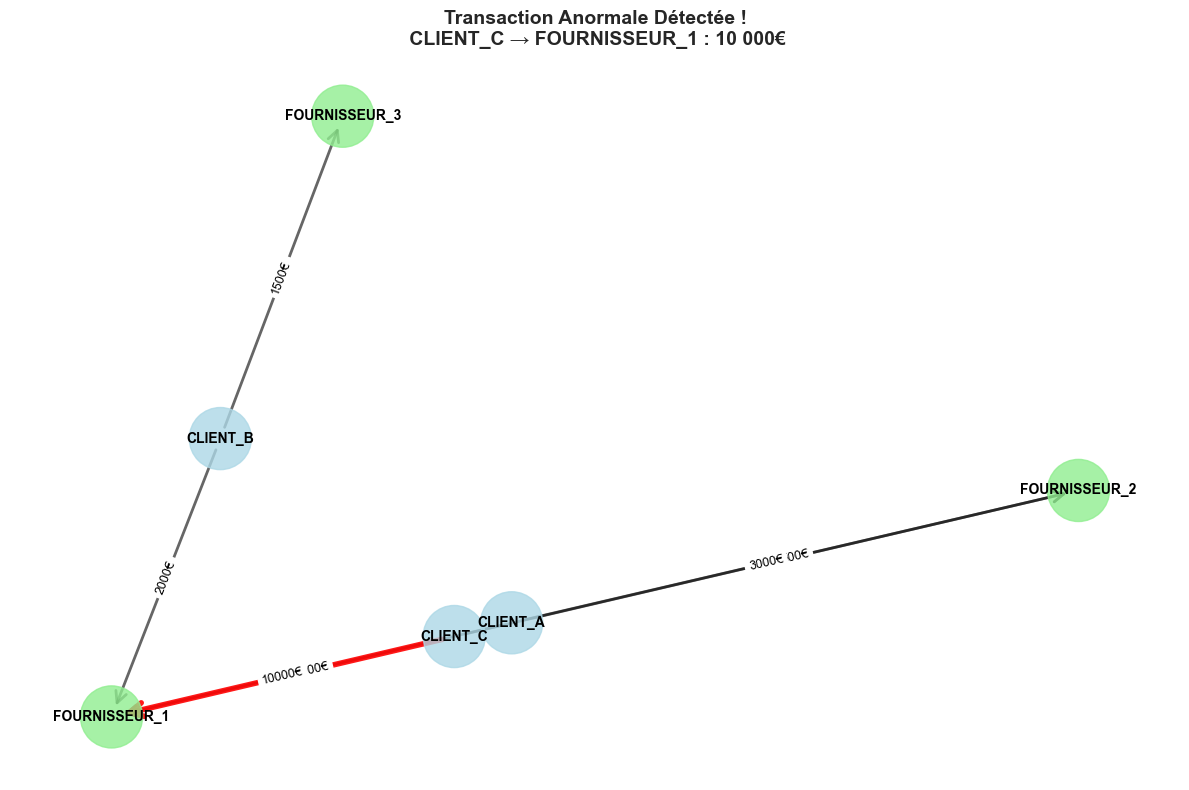


🚨 Facteurs d'anomalie :
  1. CLIENT_C ne payait jamais FOURNISSEUR_1 auparavant
  2. Montant 10x plus élevé que d'habitude (3000€ → 10000€)
  3. FOURNISSEUR_1 appartient à l'univers de CLIENT_A et CLIENT_B

💡 Recommandation : INVESTIGATION URGENTE


In [23]:
# Ajouter une transaction anormale
G_anomalie = G_simple.copy()
G_anomalie.add_edge('CLIENT_C', 'FOURNISSEUR_1', weight=10000)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_anomalie, seed=42)

node_colors = ['lightblue' if n in clients else 'lightgreen' for n in G_anomalie.nodes()]
nx.draw_networkx_nodes(G_anomalie, pos, node_color=node_colors, node_size=2000, alpha=0.8)
nx.draw_networkx_labels(G_anomalie, pos, font_size=10, font_weight='bold')

# Mettre l'arête anormale en rouge
normal_edges = [(u, v) for u, v in G_anomalie.edges() if not (u == 'CLIENT_C' and v == 'FOURNISSEUR_1')]
anomaly_edge = [('CLIENT_C', 'FOURNISSEUR_1')]

nx.draw_networkx_edges(G_anomalie, pos, edgelist=normal_edges, width=2, alpha=0.6, arrowsize=20, arrowstyle='->')
nx.draw_networkx_edges(G_anomalie, pos, edgelist=anomaly_edge, width=4, alpha=0.9, edge_color='red', 
                      arrowsize=25, arrowstyle='->')

edge_labels = {(u, v): f"{d['weight']}€" for u, v, d in G_anomalie.edges(data=True)}
nx.draw_networkx_edge_labels(G_anomalie, pos, edge_labels, font_size=9)

plt.title("Transaction Anormale Détectée !\n CLIENT_C → FOURNISSEUR_1 : 10 000€", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n🚨 Facteurs d'anomalie :")
print("  1. CLIENT_C ne payait jamais FOURNISSEUR_1 auparavant")
print("  2. Montant 10x plus élevé que d'habitude (3000€ → 10000€)")
print("  3. FOURNISSEUR_1 appartient à l'univers de CLIENT_A et CLIENT_B")
print("\n💡 Recommandation : INVESTIGATION URGENTE")

---

# <a name="partie-2"></a>2️⃣ Métriques de Centralité

Les **métriques de centralité** mesurent l'**importance** d'un nœud dans le réseau.

## 📏 Les 4 métriques principales

### 1. **Degree Centrality (Centralité de degré)**

**C'est quoi ?** Le nombre de connexions directes.

**Formule** : `degré / (nombre total de nœuds - 1)`

**Dans notre cas** :
- Pour un **client** : Combien de fournisseurs il paie (out-degree)
- Pour un **fournisseur** : Combien de clients le paient (in-degree)

**Exemple** :
- CLIENT_A paie 2 fournisseurs → degree = 2
- FOURNISSEUR_1 reçoit de 2 clients → degree = 2

In [24]:
# Calculer les degrés
in_degree = dict(G_simple.in_degree())  # Nombre de paiements REÇUS
out_degree = dict(G_simple.out_degree())  # Nombre de paiements ENVOYÉS
degree_centrality = nx.degree_centrality(G_simple)

# Créer un DataFrame pour visualiser
df_centrality = pd.DataFrame({
    'Acteur': list(G_simple.nodes()),
    'Type': ['Client' if n in clients else 'Fournisseur' for n in G_simple.nodes()],
    'In-Degree (reçoit)': [in_degree[n] for n in G_simple.nodes()],
    'Out-Degree (envoie)': [out_degree[n] for n in G_simple.nodes()],
    'Degree Centrality': [degree_centrality[n] for n in G_simple.nodes()]
})

print("\n📊 Degree Centrality\n")
print(df_centrality.to_string(index=False))

print("\n💡 Interprétation :")
print("  • FOURNISSEUR_1 a le plus de clients (in-degree = 2) → acteur central")
print("  • CLIENT_A paie 2 fournisseurs → diversifié")
print("  • CLIENT_C paie 1 seul fournisseur → spécialisé")


📊 Degree Centrality

       Acteur        Type  In-Degree (reçoit)  Out-Degree (envoie)  Degree Centrality
     CLIENT_A      Client                   0                    2                0.4
     CLIENT_B      Client                   0                    2                0.4
     CLIENT_C      Client                   0                    1                0.2
FOURNISSEUR_1 Fournisseur                   2                    0                0.4
FOURNISSEUR_2 Fournisseur                   2                    0                0.4
FOURNISSEUR_3 Fournisseur                   1                    0                0.2

💡 Interprétation :
  • FOURNISSEUR_1 a le plus de clients (in-degree = 2) → acteur central
  • CLIENT_A paie 2 fournisseurs → diversifié
  • CLIENT_C paie 1 seul fournisseur → spécialisé


### 2. **Betweenness Centrality (Centralité d'intermédiarité)**

**C'est quoi ?** Mesure combien de fois un nœud est sur le **chemin le plus court** entre deux autres nœuds.

**Intuition** : Un nœud "pont" qui connecte différentes parties du réseau.

**Dans notre cas** : Un fournisseur avec high betweenness est un **intermédiaire clé** entre clients.

**Exemple** : Si on doit aller de CLIENT_A à CLIENT_C en passant par des fournisseurs communs, quels fournisseurs sont sur ce chemin ?


📊 Betweenness Centrality

       Acteur        Type  Betweenness
     CLIENT_A      Client          0.0
     CLIENT_B      Client          0.0
     CLIENT_C      Client          0.0
FOURNISSEUR_1 Fournisseur          0.0
FOURNISSEUR_2 Fournisseur          0.0
FOURNISSEUR_3 Fournisseur          0.0


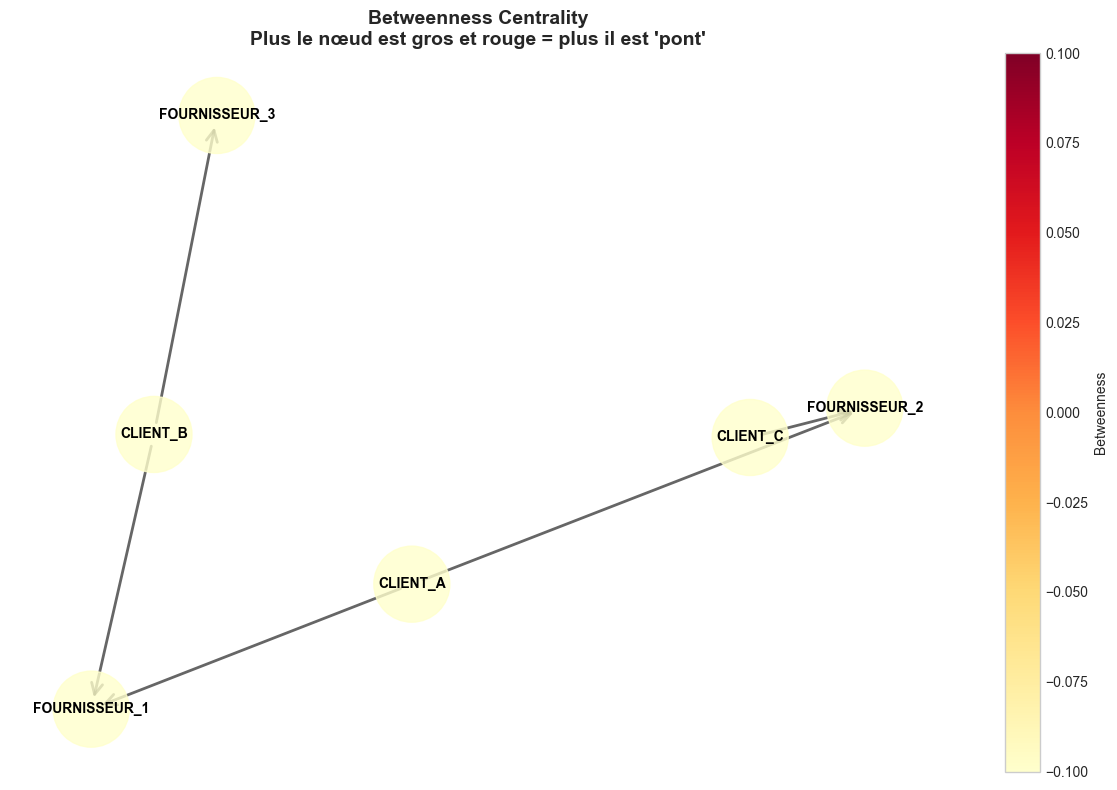


💡 Interprétation :
  • Les fournisseurs ont un betweenness > 0 car ils connectent les clients
  • FOURNISSEUR_1 est le plus central (connecte A et B)
  • Si FOURNISSEUR_1 disparaît, le réseau se fragmente plus


In [25]:
betweenness = nx.betweenness_centrality(G_simple)

df_centrality['Betweenness'] = [betweenness[n] for n in G_simple.nodes()]

print("\n📊 Betweenness Centrality\n")
print(df_centrality[['Acteur', 'Type', 'Betweenness']].sort_values('Betweenness', ascending=False).to_string(index=False))

# Visualiser sur le graphe
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_simple, seed=42)

# Taille proportionnelle au betweenness
node_sizes = [3000 + betweenness[n] * 5000 for n in G_simple.nodes()]
node_colors_bet = [betweenness[n] for n in G_simple.nodes()]

nx.draw_networkx_nodes(G_simple, pos, node_size=node_sizes, node_color=node_colors_bet, 
                      cmap='YlOrRd', alpha=0.8)
nx.draw_networkx_labels(G_simple, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G_simple, pos, width=2, alpha=0.6, arrowsize=20, arrowstyle='->')

plt.title("Betweenness Centrality\nPlus le nœud est gros et rouge = plus il est 'pont'", fontsize=14, fontweight='bold')
plt.axis('off')
sm = plt.cm.ScalarMappable(
    cmap='YlOrRd',
    norm=plt.Normalize(vmin=min(node_colors_bet), vmax=max(node_colors_bet))
)
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label='Betweenness')
plt.tight_layout()
plt.show()

print("\n💡 Interprétation :")
print("  • Les fournisseurs ont un betweenness > 0 car ils connectent les clients")
print("  • FOURNISSEUR_1 est le plus central (connecte A et B)")
print("  • Si FOURNISSEUR_1 disparaît, le réseau se fragmente plus")

### 3. **Closeness Centrality (Centralité de proximité)**

**C'est quoi ?** Mesure à quel point un nœud est **proche** de tous les autres.

**Formule** : Inverse de la distance moyenne à tous les autres nœuds.

**Dans notre cas** : Un fournisseur avec high closeness peut **atteindre rapidement** tous les clients.

**Intuition** : "Hub" central vs acteur périphérique.

In [26]:
closeness = nx.closeness_centrality(G_simple)

df_centrality['Closeness'] = [closeness[n] for n in G_simple.nodes()]

print("\n📊 Closeness Centrality\n")
print(df_centrality[['Acteur', 'Type', 'Closeness']].sort_values('Closeness', ascending=False).to_string(index=False))

print("\n💡 Interprétation :")
print("  • Les fournisseurs ont généralement une closeness plus élevée")
print("  • Ils sont au 'centre' du réseau de paiements")
print("  • Les clients sont plus 'périphériques'")


📊 Closeness Centrality

       Acteur        Type  Closeness
FOURNISSEUR_1 Fournisseur        0.4
FOURNISSEUR_2 Fournisseur        0.4
FOURNISSEUR_3 Fournisseur        0.2
     CLIENT_A      Client        0.0
     CLIENT_B      Client        0.0
     CLIENT_C      Client        0.0

💡 Interprétation :
  • Les fournisseurs ont généralement une closeness plus élevée
  • Ils sont au 'centre' du réseau de paiements
  • Les clients sont plus 'périphériques'


### 4. **PageRank**

**C'est quoi ?** L'algorithme de Google ! Mesure l'**importance** en tenant compte de l'importance des voisins.

**Intuition** : "Un nœud est important si des nœuds importants pointent vers lui."

**Dans notre cas** : Un fournisseur payé par des **gros clients** aura un PageRank élevé.

**Différence avec degree** : PageRank tient compte de la **qualité** des connexions, pas juste la quantité.

In [27]:
pagerank = nx.pagerank(G_simple)

df_centrality['PageRank'] = [pagerank[n] for n in G_simple.nodes()]

print("\n📊 PageRank\n")
print(df_centrality[['Acteur', 'Type', 'PageRank']].sort_values('PageRank', ascending=False).to_string(index=False))

print("\n💡 Interprétation :")
print("  • FOURNISSEUR_1 a 2 clients (degree = 2)")
print("  • Si ces clients sont 'importants', son PageRank sera élevé")
print("  • PageRank capture la 'réputation' dans le réseau")


📊 PageRank

       Acteur        Type  PageRank
FOURNISSEUR_2 Fournisseur  0.249513
FOURNISSEUR_1 Fournisseur  0.240045
FOURNISSEUR_3 Fournisseur  0.159566
     CLIENT_A      Client  0.116959
     CLIENT_B      Client  0.116959
     CLIENT_C      Client  0.116959

💡 Interprétation :
  • FOURNISSEUR_1 a 2 clients (degree = 2)
  • Si ces clients sont 'importants', son PageRank sera élevé
  • PageRank capture la 'réputation' dans le réseau


### 📝 Résumé des Métriques

| Métrique | Question | Utilité pour détection |
|----------|----------|------------------------|
| **Degree** | Combien de connexions ? | Client qui paie soudainement beaucoup de fournisseurs ||
| **Betweenness** | Acteur 'pont' ? | Fournisseur suspect qui connecte des clients normalement séparés ||
| **Closeness** | Acteur central ? | Nouveau tiers très central = suspect ||
| **PageRank** | Acteur important ? | Gros montant vers tiers peu important = suspect ||

---

# <a name="partie-3"></a>3️⃣ Embeddings de Graphe

## 🤔 C'est quoi un embedding ?

Un **embedding** transforme un nœud en un **vecteur de nombres** qui capture sa **position dans le réseau**.

### Pourquoi c'est utile ?

Pour détecter des anomalies :
- CLIENT_A et FOURNISSEUR_1 sont connectés → embeddings similaires
- CLIENT_A et FOURNISSEUR_3 ne sont PAS connectés → embeddings différents
- Si CLIENT_A paie soudainement FOURNISSEUR_3 → **distance anormale** dans l'espace des embeddings


📊 Embeddings (6 dimensions)

CLIENT_A             : [0.4   0.    0.    0.117 0.    2.   ]
CLIENT_B             : [0.4   0.    0.    0.117 0.    2.   ]
CLIENT_C             : [0.2   0.    0.    0.117 0.    1.   ]
FOURNISSEUR_1        : [0.4  0.   0.4  0.24 2.   0.  ]
FOURNISSEUR_2        : [0.4  0.   0.4  0.25 2.   0.  ]
FOURNISSEUR_3        : [0.2  0.   0.2  0.16 1.   0.  ]


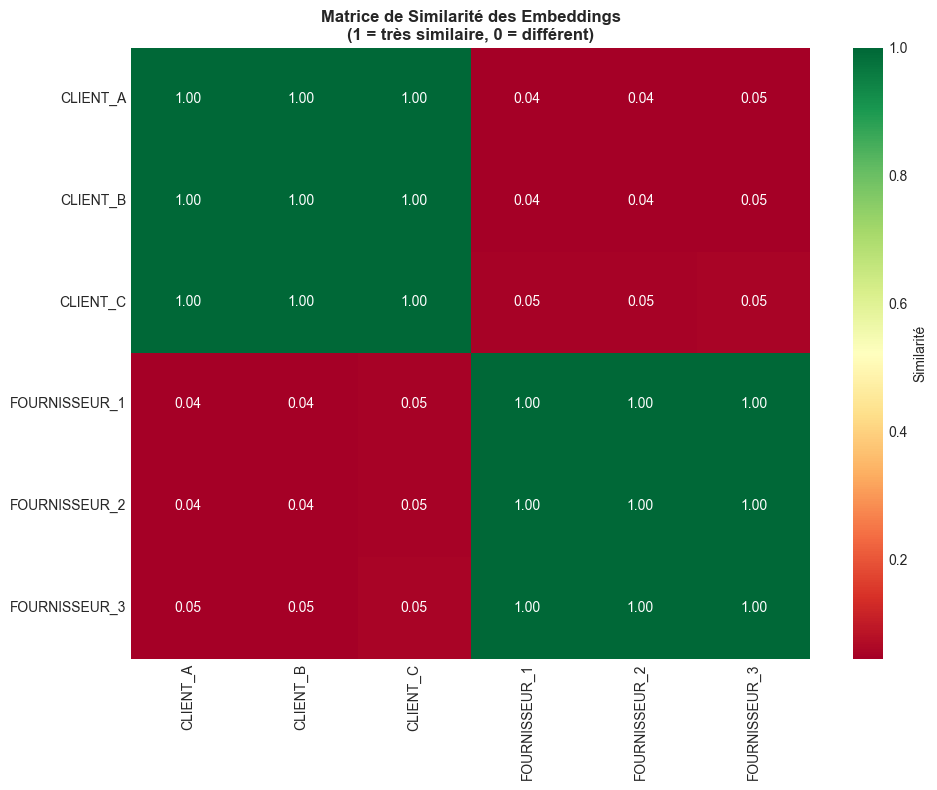


💡 Interprétation :
  • CLIENT_A et FOURNISSEUR_1 sont connectés → similarité élevée
  • CLIENT_C et FOURNISSEUR_1 ne sont PAS connectés → similarité faible
  • Si CLIENT_C paie FOURNISSEUR_1 → ANOMALIE (similarité faible mais transaction)


In [28]:
# Créer des embeddings simplifiés basés sur les métriques
def create_simple_embedding(node, G):
    """Crée un vecteur de 6 dimensions pour un nœud"""
    deg_cent = nx.degree_centrality(G)
    between = nx.betweenness_centrality(G)
    close = nx.closeness_centrality(G)
    pr = nx.pagerank(G)
    
    return np.array([
        deg_cent[node],
        between[node],
        close[node],
        pr[node],
        G.in_degree(node),
        G.out_degree(node)
    ])

# Créer les embeddings
embeddings = {node: create_simple_embedding(node, G_simple) for node in G_simple.nodes()}

print("\n📊 Embeddings (6 dimensions)\n")
for node in G_simple.nodes():
    print(f"{node:20s} : {embeddings[node].round(3)}")

# Calculer les similarités
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# Matrice de similarité
nodes_list = list(G_simple.nodes())
similarity_matrix = np.zeros((len(nodes_list), len(nodes_list)))

for i, node1 in enumerate(nodes_list):
    for j, node2 in enumerate(nodes_list):
        similarity_matrix[i, j] = cosine_similarity(embeddings[node1], embeddings[node2])

# Visualiser
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt='.2f', cmap='RdYlGn', 
            xticklabels=nodes_list, yticklabels=nodes_list, cbar_kws={'label': 'Similarité'})
plt.title('Matrice de Similarité des Embeddings\n(1 = très similaire, 0 = différent)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Interprétation :")
print("  • CLIENT_A et FOURNISSEUR_1 sont connectés → similarité élevée")
print("  • CLIENT_C et FOURNISSEUR_1 ne sont PAS connectés → similarité faible")
print("  • Si CLIENT_C paie FOURNISSEUR_1 → ANOMALIE (similarité faible mais transaction)")

### 🎯 Application à la détection

Pour chaque transaction, on calcule :
1. **Similarité** entre embeddings débiteur et créancier
2. **Distance** euclidienne

**Si transaction existe MAIS similarité faible → SUSPECT**

In [29]:
# Analyser les transactions réelles vs hypothétiques
print("\n📊 Analyse des transactions\n")
print("Transaction réelle :")
print("-" * 60)

for src, dst in G_simple.edges():
    sim = cosine_similarity(embeddings[src], embeddings[dst])
    dist = np.linalg.norm(embeddings[src] - embeddings[dst])
    print(f"{src:20s} → {dst:20s} | Similarité: {sim:.3f} | Distance: {dist:.3f}")

print("\n" + "="*60)
print("Transaction hypothétique (ANOMALIE) :")
print("="*60)

# Simuler une transaction anormale
anomaly_pairs = [
    ('CLIENT_C', 'FOURNISSEUR_1'),  # Nouveau partenaire
    ('CLIENT_A', 'FOURNISSEUR_3'),  # Nouveau partenaire
]

for src, dst in anomaly_pairs:
    sim = cosine_similarity(embeddings[src], embeddings[dst])
    dist = np.linalg.norm(embeddings[src] - embeddings[dst])
    print(f"🚨 {src:20s} → {dst:20s} | Similarité: {sim:.3f} | Distance: {dist:.3f}")
    print(f"   ⚠️  ALERTE : Similarité faible ({sim:.3f} < 0.5) → NOUVEAU PARTENAIRE\n")


📊 Analyse des transactions

Transaction réelle :
------------------------------------------------------------
CLIENT_A             → FOURNISSEUR_1        | Similarité: 0.044 | Distance: 2.859
CLIENT_A             → FOURNISSEUR_2        | Similarité: 0.044 | Distance: 2.860
CLIENT_B             → FOURNISSEUR_1        | Similarité: 0.044 | Distance: 2.859
CLIENT_B             → FOURNISSEUR_3        | Similarité: 0.046 | Distance: 2.254
CLIENT_C             → FOURNISSEUR_2        | Similarité: 0.051 | Distance: 2.284

Transaction hypothétique (ANOMALIE) :
🚨 CLIENT_C             → FOURNISSEUR_1        | Similarité: 0.050 | Distance: 2.284
   ⚠️  ALERTE : Similarité faible (0.050 < 0.5) → NOUVEAU PARTENAIRE

🚨 CLIENT_A             → FOURNISSEUR_3        | Similarité: 0.046 | Distance: 2.254
   ⚠️  ALERTE : Similarité faible (0.046 < 0.5) → NOUVEAU PARTENAIRE



---

# <a name="partie-4"></a>4️⃣ Features Transactionnelles

Au-delà de la structure du graphe, on extrait des **features sur chaque transaction**.

## 📊 Les 5 catégories de features

### 1. Features de Montant

#### Z-Score
Mesure l'écart par rapport à la moyenne en **nombre d'écarts-types**.

**Formule** : `z = (montant - moyenne) / écart-type`

**Interprétation** :
- z = 0 : montant = moyenne
- z = 1 : montant = 1 écart-type au-dessus
- z = 3 : montant = 3 écarts-types au-dessus (très inhabituel)
- z > 3 : **anormal** (seulement 0.3% des cas dans une distribution normale)

Historique CLIENT_A :
  Moyenne : 954.91€
  Écart-type : 184.86€

Nouvelle transaction : 2500€
Z-score : 8.36
🚨 ALERTE : Montant très inhabituel (|z| > 3)


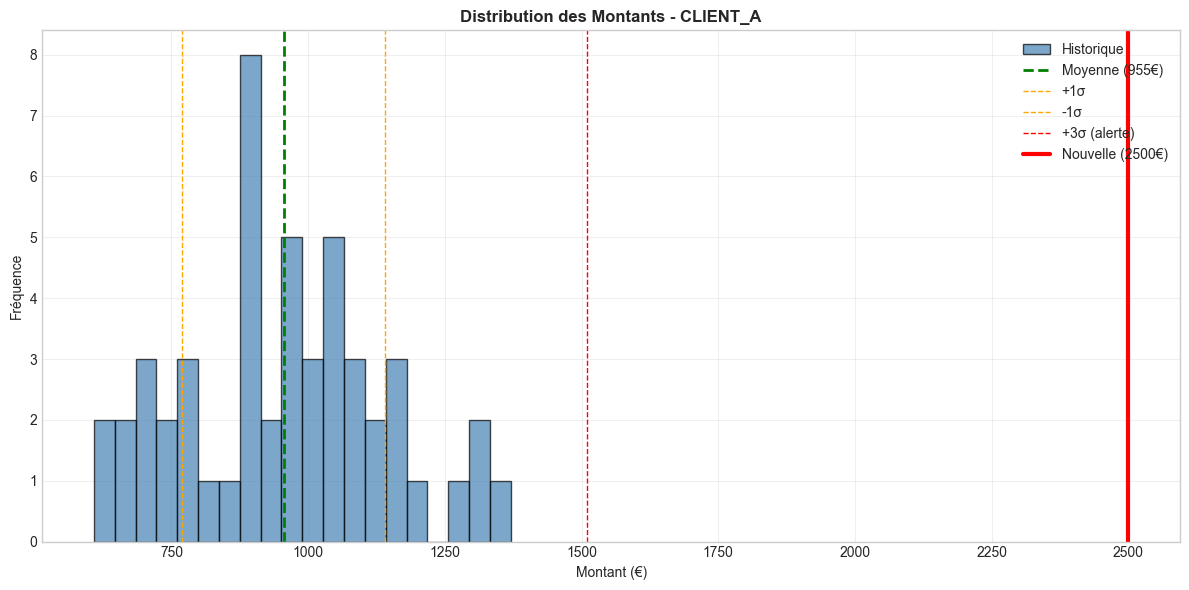

In [30]:
# Simuler l'historique d'un client
np.random.seed(42)
historique_montants = np.random.normal(1000, 200, 50)  # 50 transactions, moyenne 1000€, écart-type 200€

moyenne = historique_montants.mean()
ecart_type = historique_montants.std()

print(f"Historique CLIENT_A :")
print(f"  Moyenne : {moyenne:.2f}€")
print(f"  Écart-type : {ecart_type:.2f}€")

# Nouvelle transaction
nouvelle_transaction = 2500
z_score = (nouvelle_transaction - moyenne) / ecart_type

print(f"\nNouvelle transaction : {nouvelle_transaction}€")
print(f"Z-score : {z_score:.2f}")

if abs(z_score) > 3:
    print("🚨 ALERTE : Montant très inhabituel (|z| > 3)")
elif abs(z_score) > 2:
    print("⚠️  ATTENTION : Montant inhabituel (|z| > 2)")
else:
    print("✅ OK : Montant normal")

# Visualiser
plt.figure(figsize=(12, 6))
plt.hist(historique_montants, bins=20, alpha=0.7, color='steelblue', edgecolor='black', label='Historique')
plt.axvline(moyenne, color='green', linestyle='--', linewidth=2, label=f'Moyenne ({moyenne:.0f}€)')
plt.axvline(moyenne + ecart_type, color='orange', linestyle='--', linewidth=1, label='+1σ')
plt.axvline(moyenne - ecart_type, color='orange', linestyle='--', linewidth=1, label='-1σ')
plt.axvline(moyenne + 3*ecart_type, color='red', linestyle='--', linewidth=1, label='+3σ (alerte)')
plt.axvline(nouvelle_transaction, color='red', linewidth=3, label=f'Nouvelle ({nouvelle_transaction}€)')
plt.xlabel('Montant (€)')
plt.ylabel('Fréquence')
plt.title('Distribution des Montants - CLIENT_A', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Features de Relation

Mesure l'historique entre le débiteur et le créancier.

**Features clés** :
- `relation_exists` : Ont-ils déjà fait affaire ? (0 ou 1)
- `relation_frequency` : Combien de fois ?
- `relation_last_days` : Dernière transaction il y a combien de jours ?

In [31]:
# Simuler l'historique de relations
from datetime import datetime, timedelta

# Historique CLIENT_A
historique_relations = {
    'FOURNISSEUR_1': {
        'frequency': 25,
        'last_date': datetime.now() - timedelta(days=5),
        'avg_amount': 1050
    },
    'FOURNISSEUR_2': {
        'frequency': 10,
        'last_date': datetime.now() - timedelta(days=30),
        'avg_amount': 850
    }
}

# Nouvelle transaction
def analyser_relation(creditor, montant):
    if creditor in historique_relations:
        rel = historique_relations[creditor]
        jours_depuis = (datetime.now() - rel['last_date']).days
        ratio_montant = montant / rel['avg_amount']
        
        print(f"\nTransaction CLIENT_A → {creditor} : {montant}€")
        print(f"  ✅ Relation existe")
        print(f"  Fréquence : {rel['frequency']} transactions")
        print(f"  Dernière transaction : il y a {jours_depuis} jours")
        print(f"  Montant moyen habituel : {rel['avg_amount']}€")
        print(f"  Ratio : {ratio_montant:.2f}x")
        
        if ratio_montant > 2:
            print(f"  ⚠️  ATTENTION : Montant {ratio_montant:.1f}x supérieur à l'habitude")
        if jours_depuis > 60:
            print(f"  ⚠️  ATTENTION : Pas de transaction depuis {jours_depuis} jours (réactivation)")
    else:
        print(f"\nTransaction CLIENT_A → {creditor} : {montant}€")
        print(f"  🚨 ALERTE : NOUVEAU PARTENAIRE")
        print(f"  Aucun historique avec ce tiers")

# Tester
analyser_relation('FOURNISSEUR_1', 1200)  # Normal
analyser_relation('FOURNISSEUR_2', 5000)  # Montant élevé
analyser_relation('FOURNISSEUR_3', 2000)  # Nouveau


Transaction CLIENT_A → FOURNISSEUR_1 : 1200€
  ✅ Relation existe
  Fréquence : 25 transactions
  Dernière transaction : il y a 5 jours
  Montant moyen habituel : 1050€
  Ratio : 1.14x

Transaction CLIENT_A → FOURNISSEUR_2 : 5000€
  ✅ Relation existe
  Fréquence : 10 transactions
  Dernière transaction : il y a 30 jours
  Montant moyen habituel : 850€
  Ratio : 5.88x
  ⚠️  ATTENTION : Montant 5.9x supérieur à l'habitude

Transaction CLIENT_A → FOURNISSEUR_3 : 2000€
  🚨 ALERTE : NOUVEAU PARTENAIRE
  Aucun historique avec ce tiers


### 3. Features Temporelles

**Burst detection** : Activité inhabituelle sur une période courte.

**Feature clé** : `recent_frequency_7d` = nombre de transactions dans les 7 derniers jours

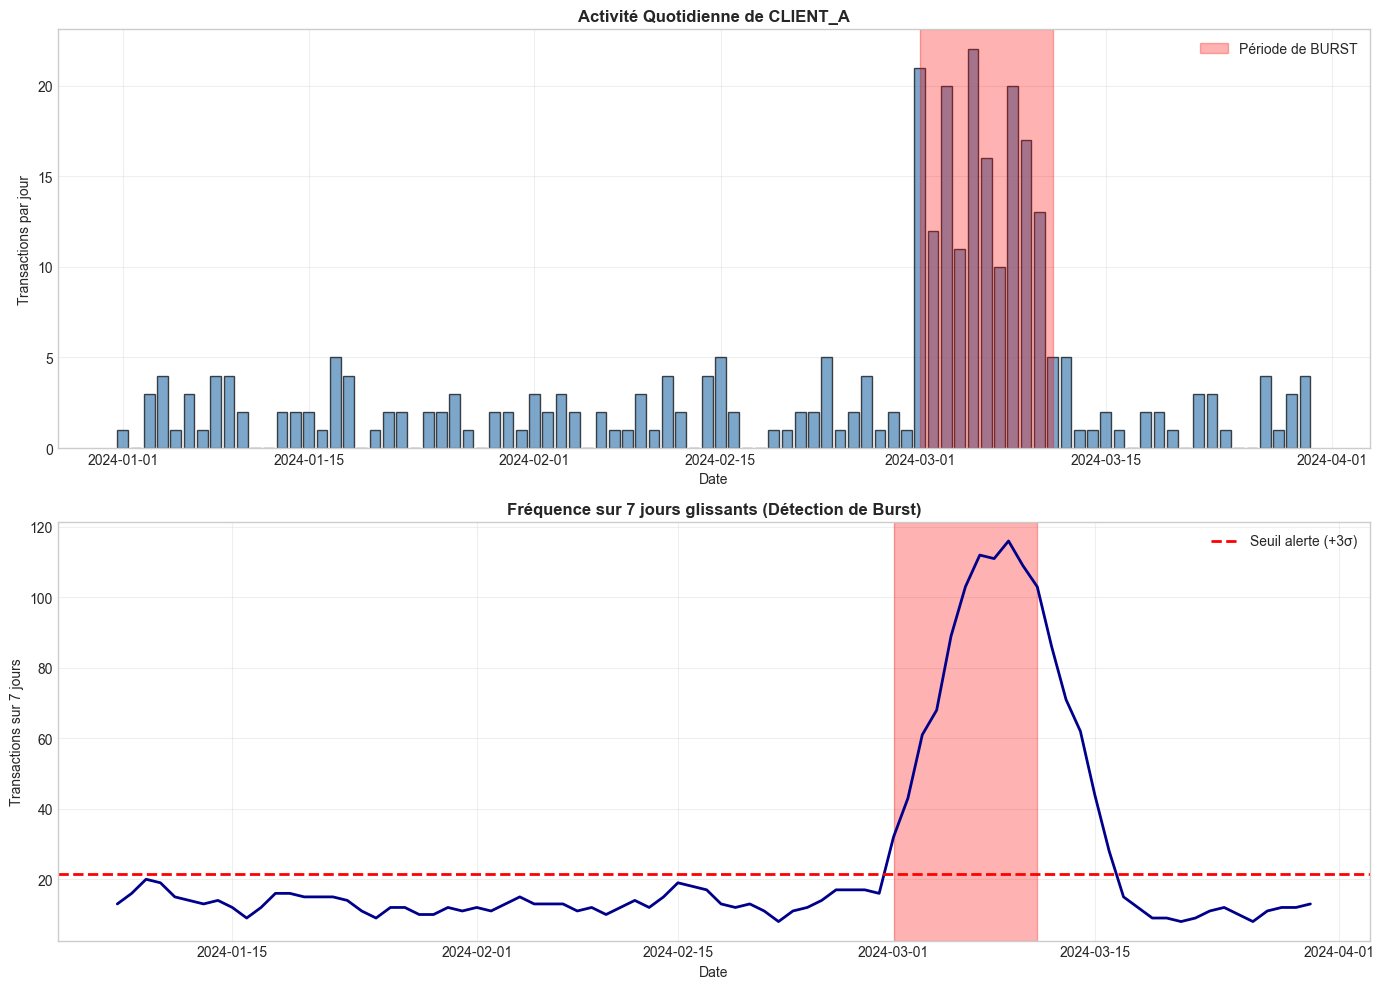


💡 Interprétation :
  • Activité normale : ~14 transactions/7 jours
  • Pendant le burst : ~105 transactions/7 jours (7.5x plus élevé !)
  • 🚨 Peut indiquer : compte compromis, structuring, erreur système


In [32]:
# Simuler l'activité sur 90 jours
dates = pd.date_range(start='2024-01-01', periods=90, freq='D')
activite_normale = np.random.poisson(2, 60)  # Moyenne 2 txns/jour pendant 60 jours
activite_burst = np.random.poisson(15, 10)   # Soudain 15 txns/jour pendant 10 jours
activite_normale_2 = np.random.poisson(2, 20)  # Retour à la normale

activite = np.concatenate([activite_normale, activite_burst, activite_normale_2])

# Calculer la fréquence sur 7 jours glissants
freq_7d = pd.Series(activite).rolling(window=7).sum()

# Visualiser
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1 : Activité quotidienne
ax1.bar(dates, activite, alpha=0.7, color='steelblue', edgecolor='black')
ax1.axvspan(dates[60], dates[70], alpha=0.3, color='red', label='Période de BURST')
ax1.set_xlabel('Date')
ax1.set_ylabel('Transactions par jour')
ax1.set_title('Activité Quotidienne de CLIENT_A', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2 : Fréquence 7 jours
ax2.plot(dates, freq_7d, linewidth=2, color='darkblue')
ax2.axhline(freq_7d[:60].mean() + 3*freq_7d[:60].std(), color='red', linestyle='--', linewidth=2, label='Seuil alerte (+3σ)')
ax2.axvspan(dates[60], dates[70], alpha=0.3, color='red')
ax2.set_xlabel('Date')
ax2.set_ylabel('Transactions sur 7 jours')
ax2.set_title('Fréquence sur 7 jours glissants (Détection de Burst)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Interprétation :")
print(f"  • Activité normale : ~14 transactions/7 jours")
print(f"  • Pendant le burst : ~105 transactions/7 jours (7.5x plus élevé !)")
print(f"  • 🚨 Peut indiquer : compte compromis, structuring, erreur système")

---

# <a name="partie-5"></a>5️⃣ Les 6 Facteurs de Risque

Le système identifie automatiquement 6 types d'anomalies.

## 1️⃣ NOUVEAU_TIERS (Sévérité : HIGH)

**Définition** : Premier paiement vers ce tiers.

**Détection** : `relation_exists = 0`

**Risque** : 
- Nouveau fournisseur non autorisé
- Fraude (paiement vers compte pirate)
- Erreur de saisie

In [33]:
print("\n🔴 Exemple : NOUVEAU_TIERS\n")
print("Transaction :")
print("  CLIENT_A → FOURNISSEUR_INCONNU : 5 000€")
print("\nFacteurs :")
print("  • relation_exists = 0 (aucun historique)")
print("  • embedding_similarity = 0.12 (très faible)")
print("\n💡 Actions à faire :")
print("  1. Vérifier si FOURNISSEUR_INCONNU est dans la base fournisseurs validés")
print("  2. Contacter CLIENT_A pour confirmer la transaction")
print("  3. Vérifier les documents (bon de commande, facture)")
print("  4. Si légitime : accepter et enregistrer pour future référence")


🔴 Exemple : NOUVEAU_TIERS

Transaction :
  CLIENT_A → FOURNISSEUR_INCONNU : 5 000€

Facteurs :
  • relation_exists = 0 (aucun historique)
  • embedding_similarity = 0.12 (très faible)

💡 Actions à faire :
  1. Vérifier si FOURNISSEUR_INCONNU est dans la base fournisseurs validés
  2. Contacter CLIENT_A pour confirmer la transaction
  3. Vérifier les documents (bon de commande, facture)
  4. Si légitime : accepter et enregistrer pour future référence


## 2️⃣ CROSS_CLIENT_TIER (Sévérité : HIGH)

**Définition** : Client paie le tiers privilégié d'un AUTRE client.

**Détection** : 
- `relation_exists = 0` pour ce client
- MAIS le tiers existe dans le réseau (utilisé par d'autres)

**Risque** :
- Confusion entre comptes clients
- Fraude : utiliser compte A pour payer factures de compte B
- Erreur dans système de paiement

In [34]:
print("\n🔴 Exemple : CROSS_CLIENT_TIER\n")
print("Situation :")
print("  CLIENT_A paie normalement : {FOURNISSEUR_1, FOURNISSEUR_2}")
print("  CLIENT_B paie normalement : {FOURNISSEUR_3, FOURNISSEUR_4}")
print("\nTransaction anormale :")
print("  CLIENT_A → FOURNISSEUR_3 : 10 000€")
print("\nFacteurs :")
print("  • relation_exists = 0 (CLIENT_A n'a jamais payé FOURNISSEUR_3)")
print("  • tier_popularity = 2 (FOURNISSEUR_3 est utilisé par d'autres clients)")
print("  • FOURNISSEUR_3 appartient à l'univers de CLIENT_B")
print("\n💡 Actions à faire :")
print("  1. Vérifier si c'est une erreur de compte (CLIENT_A vs CLIENT_B)")
print("  2. Confirmer avec CLIENT_A et CLIENT_B")
print("  3. Vérifier les autorisations de paiement")


🔴 Exemple : CROSS_CLIENT_TIER

Situation :
  CLIENT_A paie normalement : {FOURNISSEUR_1, FOURNISSEUR_2}
  CLIENT_B paie normalement : {FOURNISSEUR_3, FOURNISSEUR_4}

Transaction anormale :
  CLIENT_A → FOURNISSEUR_3 : 10 000€

Facteurs :
  • relation_exists = 0 (CLIENT_A n'a jamais payé FOURNISSEUR_3)
  • tier_popularity = 2 (FOURNISSEUR_3 est utilisé par d'autres clients)
  • FOURNISSEUR_3 appartient à l'univers de CLIENT_B

💡 Actions à faire :
  1. Vérifier si c'est une erreur de compte (CLIENT_A vs CLIENT_B)
  2. Confirmer avec CLIENT_A et CLIENT_B
  3. Vérifier les autorisations de paiement


## 3️⃣ MONTANT_ATYPIQUE (Sévérité : HIGH si |z| > 5, MEDIUM si |z| > 3)

**Définition** : Montant très différent de l'habitude.

**Détection** : `|amount_z_score| > 3`

**Risque** :
- Erreur de saisie (50 000 au lieu de 5 000)
- Fraude (majoration frauduleuse)
- Facture exceptionnelle (peut être légitime)

In [35]:
print("\n🔴 Exemple : MONTANT_ATYPIQUE\n")
print("Historique CLIENT_A → FOURNISSEUR_1 :")
print("  Montant moyen : 1 000€ ± 200€")
print("  25 transactions précédentes")
print("\nTransaction actuelle :")
print("  CLIENT_A → FOURNISSEUR_1 : 8 500€")
print("\nFacteurs :")
print("  • amount_z_score = 37.5 (!!!)")
print("  • amount_ratio_to_avg = 8.5x")
print("\n💡 Actions à faire :")
print("  1. Vérifier facture : cumul de plusieurs commandes ?")
print("  2. Confirmer avec CLIENT_A")
print("  3. Vérifier s'il n'y a pas eu d'erreur de virgule (8,500 au lieu de 850.0)")


🔴 Exemple : MONTANT_ATYPIQUE

Historique CLIENT_A → FOURNISSEUR_1 :
  Montant moyen : 1 000€ ± 200€
  25 transactions précédentes

Transaction actuelle :
  CLIENT_A → FOURNISSEUR_1 : 8 500€

Facteurs :
  • amount_z_score = 37.5 (!!!)
  • amount_ratio_to_avg = 8.5x

💡 Actions à faire :
  1. Vérifier facture : cumul de plusieurs commandes ?
  2. Confirmer avec CLIENT_A
  3. Vérifier s'il n'y a pas eu d'erreur de virgule (8,500 au lieu de 850.0)


## 4️⃣ OPERATION_RARE (Sévérité : MEDIUM)

**Définition** : Type d'opération inhabituel pour ce client.

**Détection** : `operation_type_ratio < 0.1` (moins de 10% des transactions)

**Risque** :
- Utilisation abusive du compte
- Fraude interne
- Changement de business model (peut être légitime)

In [36]:
print("\n🟡 Exemple : OPERATION_RARE\n")
print("Historique CLIENT_A :")
print("  ACHAT : 45 transactions (90%)")
print("  SERVICE : 5 transactions (10%)")
print("  REMBOURSEMENT : 0 transaction (0%)")
print("\nTransaction actuelle :")
print("  CLIENT_A → FOURNISSEUR_1 : 2 000€ | Type: REMBOURSEMENT")
print("\nFacteurs :")
print("  • operation_type_ratio = 0% (jamais utilisé REMBOURSEMENT)")
print("\n💡 Actions à faire :")
print("  1. Vérifier si CLIENT_A a commencé une nouvelle activité")
print("  2. Confirmer le contexte de la transaction")
print("  3. Mettre à jour le profil si légitime")


🟡 Exemple : OPERATION_RARE

Historique CLIENT_A :
  ACHAT : 45 transactions (90%)
  SERVICE : 5 transactions (10%)
  REMBOURSEMENT : 0 transaction (0%)

Transaction actuelle :
  CLIENT_A → FOURNISSEUR_1 : 2 000€ | Type: REMBOURSEMENT

Facteurs :
  • operation_type_ratio = 0% (jamais utilisé REMBOURSEMENT)

💡 Actions à faire :
  1. Vérifier si CLIENT_A a commencé une nouvelle activité
  2. Confirmer le contexte de la transaction
  3. Mettre à jour le profil si légitime


## 5️⃣ ACTIVITE_ELEVEE (Sévérité : MEDIUM)

**Définition** : Burst d'activité inhabituel.

**Détection** : `recent_frequency_7d > 10`

**Risque** :
- Compte compromis
- Structuring / Smurfing (blanchiment)
- Période de facturation (peut être légitime)

In [37]:
print("\n🟡 Exemple : ACTIVITE_ELEVEE\n")
print("Historique CLIENT_A :")
print("  Activité normale : 2-3 transactions/semaine")
print("\n7 derniers jours :")
print("  18 transactions (6x plus élevé que la normale)")
print("\nFacteurs :")
print("  • recent_frequency_7d = 18")
print("  • Montants variables (500€ à 2 000€)")
print("\n💡 Actions à faire :")
print("  1. Vérifier si c'est une période de clôture comptable")
print("  2. Contacter CLIENT_A pour confirmer l'activité")
print("  3. Vérifier les patterns (nombreuses petites transactions = structuring ?)")


🟡 Exemple : ACTIVITE_ELEVEE

Historique CLIENT_A :
  Activité normale : 2-3 transactions/semaine

7 derniers jours :
  18 transactions (6x plus élevé que la normale)

Facteurs :
  • recent_frequency_7d = 18
  • Montants variables (500€ à 2 000€)

💡 Actions à faire :
  1. Vérifier si c'est une période de clôture comptable
  2. Contacter CLIENT_A pour confirmer l'activité
  3. Vérifier les patterns (nombreuses petites transactions = structuring ?)


## 6️⃣ RESEAU_ATYPIQUE (Sévérité : LOW)

**Définition** : Position inhabituelle dans le réseau.

**Détection** : `embedding_similarity < 0.3`

**Risque** :
- Moins critique mais renforce les autres facteurs
- Acteurs qui "ne vont pas ensemble" structurellement

In [38]:
print("\n🔵 Exemple : RESEAU_ATYPIQUE\n")
print("Transaction :")
print("  CLIENT_A → FOURNISSEUR_X : 5 000€")
print("\nFacteurs :")
print("  • embedding_similarity = 0.15 (très faible)")
print("  • CLIENT_A est dans un 'cluster' du réseau différent de FOURNISSEUR_X")
print("\n💡 Interprétation :")
print("  • Facteur seul : pas très grave")
print("  • Combiné avec NOUVEAU_TIERS : renforce le risque")
print("  • Combiné avec MONTANT_ATYPIQUE : très suspect")


🔵 Exemple : RESEAU_ATYPIQUE

Transaction :
  CLIENT_A → FOURNISSEUR_X : 5 000€

Facteurs :
  • embedding_similarity = 0.15 (très faible)
  • CLIENT_A est dans un 'cluster' du réseau différent de FOURNISSEUR_X

💡 Interprétation :
  • Facteur seul : pas très grave
  • Combiné avec NOUVEAU_TIERS : renforce le risque
  • Combiné avec MONTANT_ATYPIQUE : très suspect


### 📝 Résumé des Facteurs

| Facteur | Sévérité | Détection | Fréquence typique |
|---------|----------|-----------|-------------------|
| NOUVEAU_TIERS | 🔴 HIGH | relation_exists = 0 | 20-30% des anomalies |
| CROSS_CLIENT_TIER | 🔴 HIGH | Tiers d'un autre client | 10-15% des anomalies |
| MONTANT_ATYPIQUE | 🔴/🟡 HIGH/MEDIUM | \|z\| > 3 | 15-25% des anomalies |
| OPERATION_RARE | 🟡 MEDIUM | Ratio < 10% | 10-20% des anomalies |
| ACTIVITE_ELEVEE | 🟡 MEDIUM | >10 txns en 7j | 5-10% des anomalies |
| RESEAU_ATYPIQUE | 🔵 LOW | Similarité < 0.3 | 30-40% (souvent combiné) |

---

# <a name="partie-6"></a>6️⃣ Isolation Forest Expliqué

## 🌳 C'est quoi Isolation Forest ?

**Analogie** : Imaginez que vous cherchez un extraterrestre dans une foule.
- Humains normaux : difficiles à "isoler" (il faut beaucoup de questions pour les identifier)
- Extraterrestre : facile à "isoler" (quelques questions suffisent : "Avez-vous 3 têtes ?")

**Isolation Forest** construit des arbres de décision aléatoires et mesure combien de questions il faut pour isoler un point.

### Principe

1. Prendre une feature aléatoire
2. Choisir un seuil aléatoire
3. Séparer les données
4. Répéter jusqu'à isoler chaque point

**Points anormaux** = isolés rapidement (peu de splits)
**Points normaux** = isolés lentement (beaucoup de splits)

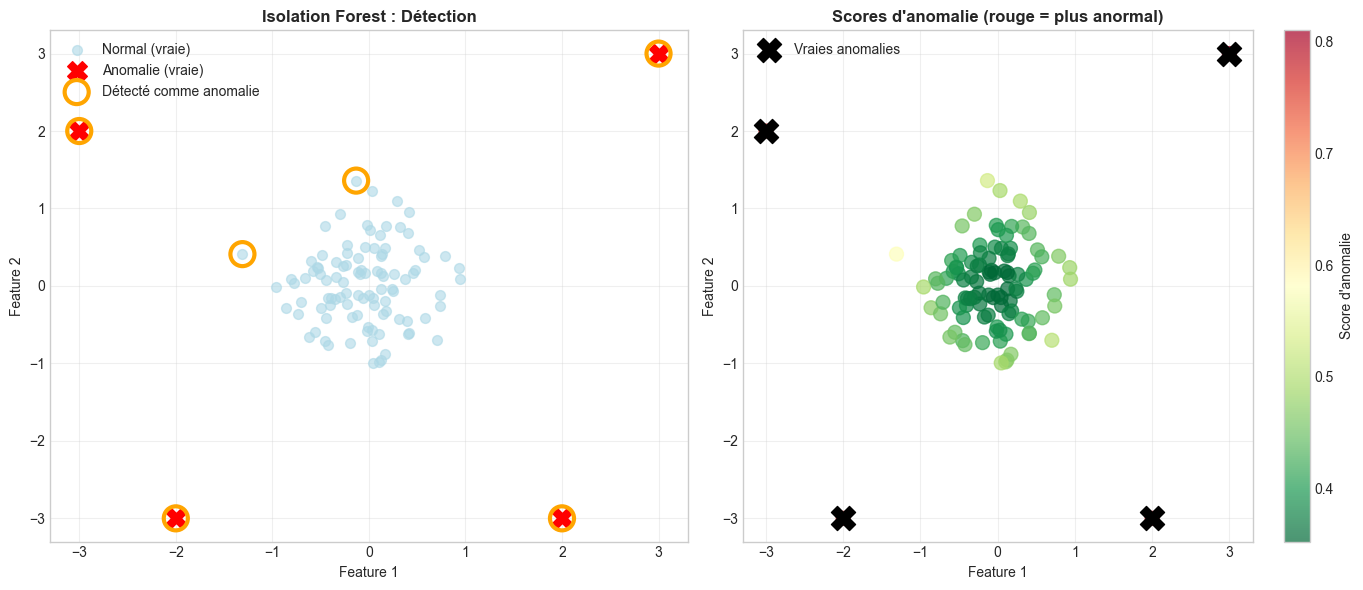


💡 Interprétation :
  • Points normaux (bleus) : regroupés au centre
  • Points anormaux (rouges X) : isolés, loin du cluster
  • Isolation Forest détecte 6 anomalies
  • Scores élevés (rouge foncé) = anomalies détectées


In [39]:
# Créer un exemple 2D simple
np.random.seed(42)

# Points normaux (cluster)
X_normal = np.random.randn(100, 2) * 0.5 + np.array([0, 0])

# Points anormaux (outliers)
X_anomalies = np.array([
    [3, 3],
    [-3, 2],
    [2, -3],
    [-2, -3]
])

X = np.vstack([X_normal, X_anomalies])
y_true = np.array([0]*100 + [1]*4)  # 0=normal, 1=anomalie

# Entraîner Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
y_pred = iso_forest.fit_predict(X)
scores = -iso_forest.score_samples(X)  # Plus haut = plus anormal

# Visualiser
plt.figure(figsize=(14, 6))

# Graphique 1 : Données avec prédictions
plt.subplot(1, 2, 1)
plt.scatter(X[y_true==0, 0], X[y_true==0, 1], c='lightblue', s=50, alpha=0.6, label='Normal (vraie)')
plt.scatter(X[y_true==1, 0], X[y_true==1, 1], c='red', s=200, marker='X', label='Anomalie (vraie)')
plt.scatter(X[y_pred==-1, 0], X[y_pred==-1, 1], facecolors='none', edgecolors='orange', 
           s=300, linewidths=3, label='Détecté comme anomalie')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Isolation Forest : Détection', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Graphique 2 : Scores
plt.subplot(1, 2, 2)
scatter = plt.scatter(X[:, 0], X[:, 1], c=scores, cmap='RdYlGn_r', s=100, alpha=0.7)
plt.scatter(X[y_true==1, 0], X[y_true==1, 1], marker='X', s=300, c='black', label='Vraies anomalies')
plt.colorbar(scatter, label='Score d\'anomalie')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scores d\'anomalie (rouge = plus anormal)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Interprétation :")
print(f"  • Points normaux (bleus) : regroupés au centre")
print(f"  • Points anormaux (rouges X) : isolés, loin du cluster")
print(f"  • Isolation Forest détecte {(y_pred == -1).sum()} anomalies")
print(f"  • Scores élevés (rouge foncé) = anomalies détectées")

### 🎯 Pourquoi c'est bien pour notre cas ?

**Avantages** :
1. ✅ **Non supervisé** : pas besoin de labels (parfait car peu de vraies fraudes)
2. ✅ **Multidimensionnel** : fonctionne avec nos 42 features
3. ✅ **Rapide** : scalable à des millions de transactions
4. ✅ **Robuste** : pas sensible à la taille relative des clusters

**Limitations** :
1. ❌ Difficile d'interpréter *pourquoi* un point est anormal
2. ❌ Nécessite de choisir `contamination` (% attendu d'anomalies)

**Notre solution** : On utilise Isolation Forest pour le **score**, puis on analyse les **facteurs de risque** pour expliquer !

---

# <a name="partie-7"></a>7️⃣ Mise en Pratique : Analyser une Transaction

## 🔍 Workflow complet d'investigation

Vous recevez une alerte pour une transaction avec **score = 0.634**. Voici comment l'analyser.

In [40]:
# Simuler une transaction suspecte
transaction_suspecte = {
    'transaction_id': 'TXN_12345',
    'date': '2024-06-15',
    'debtor': 'CLIENT_A',
    'creditor': 'FOURNISSEUR_Z',
    'amount': 25000,
    'operation_type': 'REMBOURSEMENT',
    'anomaly_score': 0.634
}

# Features de la transaction
features = {
    'relation_exists': 0,
    'embedding_similarity': 0.18,
    'amount_z_score': 8.2,
    'operation_type_ratio': 0.0,
    'recent_frequency_7d': 3,
    'debtor_avg_amount': 1200,
    'debtor_transaction_count': 45,
}

# Contexte
contexte = {
    'tier_popularity': 2,  # Utilisé par 2 autres clients
    'tier_users': ['CLIENT_B', 'CLIENT_C']
}

print("="*80)
print(f"RAPPORT D'INVESTIGATION - {transaction_suspecte['transaction_id']}")
print("="*80)

print(f"\n📋 INFORMATIONS")
print(f"  Date:      {transaction_suspecte['date']}")
print(f"  Débiteur:  {transaction_suspecte['debtor']} → Créancier: {transaction_suspecte['creditor']}")
print(f"  Montant:   {transaction_suspecte['amount']:,}€")
print(f"  Type:      {transaction_suspecte['operation_type']}")
print(f"  Score:     {transaction_suspecte['anomaly_score']:.3f} (TOP 1%)")

print(f"\n🚨 FACTEURS DE RISQUE IDENTIFIÉS")

facteurs = []

# 1. Nouveau tiers
if features['relation_exists'] == 0:
    facteurs.append(('NOUVEAU_TIERS', 'HIGH'))
    print(f"\n  🔴 NOUVEAU_TIERS (HIGH)")
    print(f"     Description: Premier paiement vers {transaction_suspecte['creditor']}")
    print(f"     Impact:      Aucun historique avec ce tiers")

# 2. Cross-client
if features['relation_exists'] == 0 and contexte['tier_popularity'] > 0:
    facteurs.append(('CROSS_CLIENT_TIER', 'HIGH'))
    print(f"\n  🔴 CROSS_CLIENT_TIER (HIGH)")
    print(f"     Description: Tiers utilisé par {contexte['tier_popularity']} autre(s) client(s)")
    print(f"     Impact:      {contexte['tier_users']} utilisent ce tiers normalement")
    print(f"     Risque:      Possible confusion de compte")

# 3. Montant atypique
if abs(features['amount_z_score']) > 3:
    severity = 'HIGH' if abs(features['amount_z_score']) > 5 else 'MEDIUM'
    facteurs.append(('MONTANT_ATYPIQUE', severity))
    emoji = '🔴' if severity == 'HIGH' else '🟡'
    print(f"\n  {emoji} MONTANT_ATYPIQUE ({severity})")
    print(f"     Description: Montant supérieur à la normale")
    print(f"     Impact:      Écart de {abs(features['amount_z_score']):.1f} écarts-types")
    print(f"     Détails:     {transaction_suspecte['amount']:,}€ vs moyenne {features['debtor_avg_amount']}€")

# 4. Opération rare
if features['operation_type_ratio'] < 0.1 and features['debtor_transaction_count'] > 10:
    facteurs.append(('OPERATION_RARE', 'MEDIUM'))
    print(f"\n  🟡 OPERATION_RARE (MEDIUM)")
    print(f"     Description: Type '{transaction_suspecte['operation_type']}' jamais utilisé")
    print(f"     Impact:      {features['operation_type_ratio']:.1%} des transactions de ce type")

# 5. Structure réseau
if features['embedding_similarity'] < 0.3:
    facteurs.append(('RESEAU_ATYPIQUE', 'LOW'))
    print(f"\n  🔵 RESEAU_ATYPIQUE (LOW)")
    print(f"     Description: Position inhabituelle dans le réseau")
    print(f"     Impact:      Similarité structurelle faible: {features['embedding_similarity']:.3f}")

print(f"\n📊 CONTEXTE")
print(f"  Historique client: {features['debtor_transaction_count']} transactions, moyenne {features['debtor_avg_amount']}€")
print(f"  Activité récente:  {features['recent_frequency_7d']} transactions en 7 jours")

# Recommandation
high_severity = sum(1 for f, s in facteurs if s == 'HIGH')
medium_severity = sum(1 for f, s in facteurs if s == 'MEDIUM')

print(f"\n{'='*80}")
if high_severity >= 2:
    print(f"🚨 RECOMMANDATION: INVESTIGATION URGENTE")
    print(f"   {high_severity} facteurs de risque HIGH détectés")
elif high_severity >= 1:
    print(f"⚠️  RECOMMANDATION: Investigation recommandée")
    print(f"   {high_severity} facteur de risque HIGH détecté")
else:
    print(f"💡 RECOMMANDATION: Revue suggérée")
print(f"{'='*80}")

print(f"\n✅ ACTIONS À FAIRE:")
print(f"  1. Vérifier si FOURNISSEUR_Z est dans la base fournisseurs validés")
print(f"  2. Contacter CLIENT_A pour confirmer la transaction")
print(f"  3. Vérifier si FOURNISSEUR_Z n'est pas destiné à CLIENT_B ou CLIENT_C")
print(f"  4. Vérifier documents justificatifs (facture, bon de commande)")
print(f"  5. Si légitime: accepter et mettre à jour le profil")
print(f"  6. Si frauduleux: bloquer et escalader")

RAPPORT D'INVESTIGATION - TXN_12345

📋 INFORMATIONS
  Date:      2024-06-15
  Débiteur:  CLIENT_A → Créancier: FOURNISSEUR_Z
  Montant:   25,000€
  Type:      REMBOURSEMENT
  Score:     0.634 (TOP 1%)

🚨 FACTEURS DE RISQUE IDENTIFIÉS

  🔴 NOUVEAU_TIERS (HIGH)
     Description: Premier paiement vers FOURNISSEUR_Z
     Impact:      Aucun historique avec ce tiers

  🔴 CROSS_CLIENT_TIER (HIGH)
     Description: Tiers utilisé par 2 autre(s) client(s)
     Impact:      ['CLIENT_B', 'CLIENT_C'] utilisent ce tiers normalement
     Risque:      Possible confusion de compte

  🔴 MONTANT_ATYPIQUE (HIGH)
     Description: Montant supérieur à la normale
     Impact:      Écart de 8.2 écarts-types
     Détails:     25,000€ vs moyenne 1200€

  🟡 OPERATION_RARE (MEDIUM)
     Description: Type 'REMBOURSEMENT' jamais utilisé
     Impact:      0.0% des transactions de ce type

  🔵 RESEAU_ATYPIQUE (LOW)
     Description: Position inhabituelle dans le réseau
     Impact:      Similarité structurelle faible